Running Monte Carlo estimation...


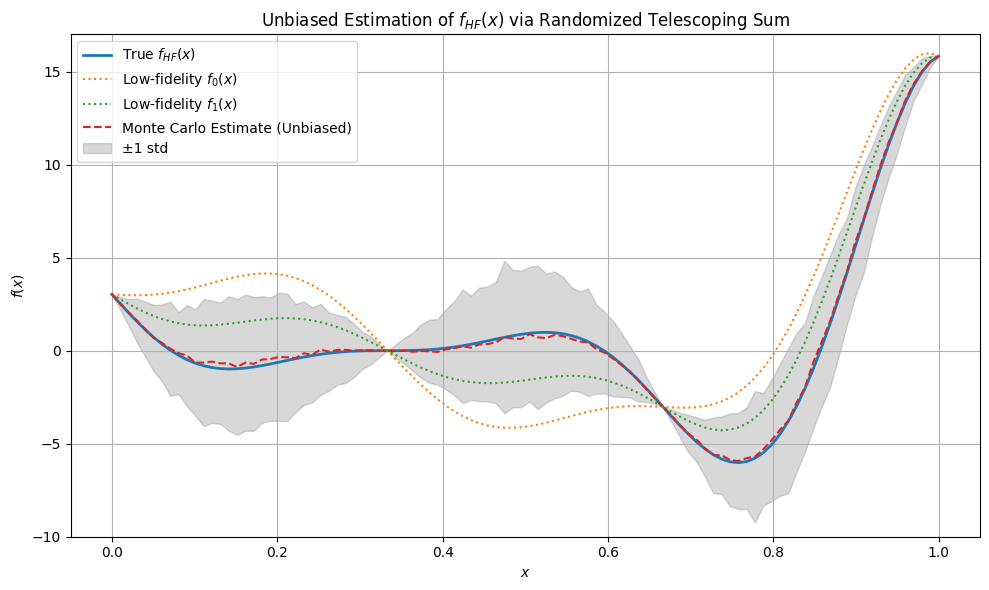

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Forrester HF function (standard domain [0,1])
def f_HF(x):
    return (6 * x - 2)**2 * np.sin(12 * x - 4)

# Create a sequence of LF approximations converging to f_HF
def f_k(x, k):
    """Low-fidelity version with increasing resolution as k increases."""
    return f_HF(x) + 5 * np.sin(3 * np.pi * x) / (k + 1) # + 4 * np.cos(7 * np.pi * x) / (k + 1)**2

# Telescoping difference
def delta_k(x, k):
    return f_k(x, k) - f_k(x, k - 1) if k > 0 else f_k(x, 0)

# Russian roulette weight: w_k = 1 / P(T ≥ k)
def survival_prob(k, p):
    return (1 - p)**k

# Extended version: return estimator + trace info
def russian_roulette_estimate_trace(x, p, max_K=30):
    T = np.random.geometric(p) - 1
    T = min(T, max_K)

    estimate = 0.0
    fks = []
    partial_sums = []

    for k in range(T + 1):
        w_k = 1.0 / survival_prob(k, p)
        delta = delta_k(x, k)
        estimate += w_k * delta
        fks.append(f_k(x, k))
        partial_sums.append(estimate)

    return estimate, fks, partial_sums, T

# Monte Carlo estimation at a single x
def monte_carlo_estimation(x, p=0.2, N=10000):
    estimates = [russian_roulette_estimate_trace(x, p)[0] for _ in range(N)]
    mean_est = np.mean(estimates)
    std_est = np.std(estimates)
    true_val = f_HF(x)
    return mean_est, std_est, true_val

# --- First plot: Monte Carlo over grid
x_grid = np.linspace(0, 1, 100)
mean_preds = []
std_preds = []
true_vals = []

print("Running Monte Carlo estimation...")
for x in x_grid:
    mean, std, true = monte_carlo_estimation(x, p=0.2, N=1000)
    mean_preds.append(mean)
    std_preds.append(std)
    true_vals.append(true)

plt.figure(figsize=(10,6))
plt.plot(x_grid, true_vals, label='True $f_{HF}(x)$', linewidth=2)
plt.plot(x_grid, f_k(x_grid, 0), label='Low-fidelity $f_0(x)$', linestyle=':')
plt.plot(x_grid, f_k(x_grid, 1), label='Low-fidelity $f_1(x)$', linestyle=':')
plt.plot(x_grid, mean_preds, label='Monte Carlo Estimate (Unbiased)', linestyle='--')
plt.fill_between(x_grid,
                 np.array(mean_preds) - np.array(std_preds),
                 np.array(mean_preds) + np.array(std_preds),
                 color='gray', alpha=0.3, label='±1 std')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.ylim(-10, 17)
plt.title('Unbiased Estimation of $f_{HF}(x)$ via Randomized Telescoping Sum')
plt.grid(True)
plt.tight_layout()
plt.show()

In [2]:
num_LF_list = np.append(np.arange(100, 1005, 200), 1004)
num_HF_list = np.arange(1, 8)
holdout_list = np.arange(4)

len(num_LF_list) * len(num_HF_list) * len(holdout_list) * 3 / 60

8.4

In [3]:
num_LF_list

array([ 100,  300,  500,  700,  900, 1004])

Plotting used f_k(x) in a single estimator run...


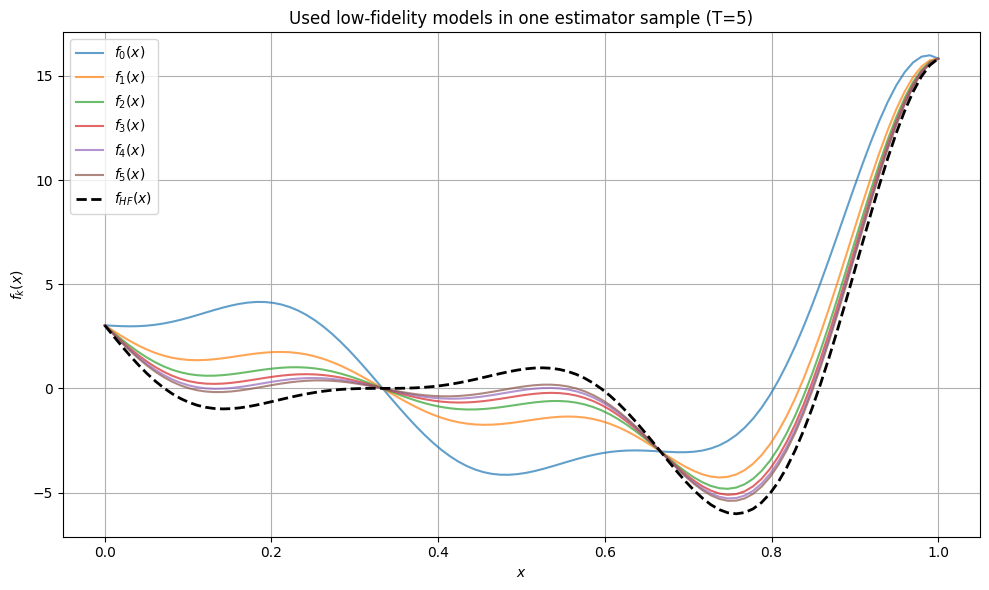

In [4]:
# ---------- Second plot: used low-fidelity functions in one estimator ----------
# Trace estimator with full x-grid output
def russian_roulette_estimate_trace_grid(x_grid, p, max_K=100):
    T = np.random.geometric(p) - 1
    T = min(T, max_K)

    fk_list = []
    partial_sums = []

    estimate = np.zeros_like(x_grid)

    for k in range(T + 1):
        w_k = 1.0 / survival_prob(k, p)
        delta = delta_k(x_grid, k)
        estimate += w_k * delta
        fk_list.append(f_k(x_grid, k))              # used fidelity function
        partial_sums.append(estimate.copy())        # current estimator state

    return estimate, fk_list, partial_sums, T

print("Plotting used f_k(x) in a single estimator run...")
_, fk_used_list, partial_sums, T = russian_roulette_estimate_trace_grid(x_grid, p=0.2)

plt.figure(figsize=(10,6))
for k, fk in enumerate(fk_used_list):
    plt.plot(x_grid, fk, label=f'$f_{k}(x)$', alpha=0.7)
plt.plot(x_grid, f_HF(x_grid), 'k--', label='$f_{HF}(x)$', linewidth=2)
plt.xlabel('$x$')
plt.ylabel('$f_k(x)$')
plt.title(f'Used low-fidelity models in one estimator sample (T={T})')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Plotting improved convergence with MC mean...


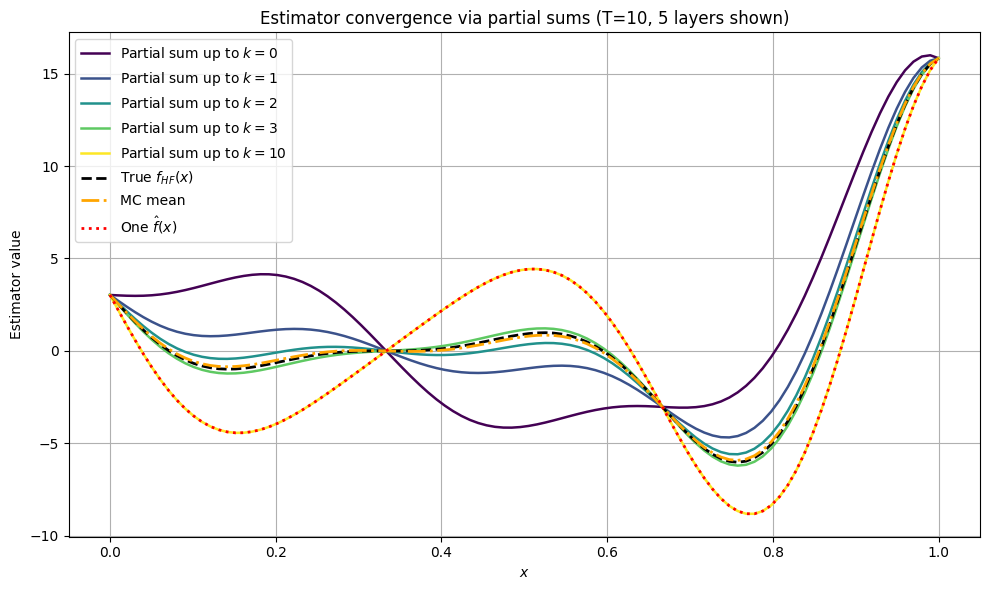

In [5]:
# ---------- Third plot: convergence of partial sums (improved) ----------
print("Plotting improved convergence with MC mean...")

# 再跑一次 estimator trace，抓 partial sums
est_single, _, partial_sums, T = russian_roulette_estimate_trace_grid(x_grid, p=0.2)

# 預先算一個 MC mean，用較小 sample 數
N_mc = 500
mc_samples = [russian_roulette_estimate_trace_grid(x_grid, p=0.2)[0] for _ in range(N_mc)]
mc_mean = np.mean(mc_samples, axis=0)

# 選幾層畫線（避免太擁擠）
layers_to_plot = list(sorted(set([0, 1, 2, 3, T])))

plt.figure(figsize=(10,6))
colors = plt.cm.viridis(np.linspace(0, 1, len(layers_to_plot)))

for i, k in enumerate(layers_to_plot):
    plt.plot(x_grid, partial_sums[k], color=colors[i], label=f'Partial sum up to $k={k}$', linewidth=1.8)

# 真實值、MC 平均值、單次 estimate
plt.plot(x_grid, f_HF(x_grid), 'k--', linewidth=2, label='True $f_{HF}(x)$')
plt.plot(x_grid, mc_mean, color='orange', linestyle='-.', linewidth=2, label='MC mean')
plt.plot(x_grid, est_single, color='red', linestyle=':', linewidth=2, label='One $\hat{{f}}(x)$')

plt.xlabel('$x$')
plt.ylabel('Estimator value')
plt.title(f'Estimator convergence via partial sums (T={T}, {len(layers_to_plot)} layers shown)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

2025-04-14 13:16:17.602398: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


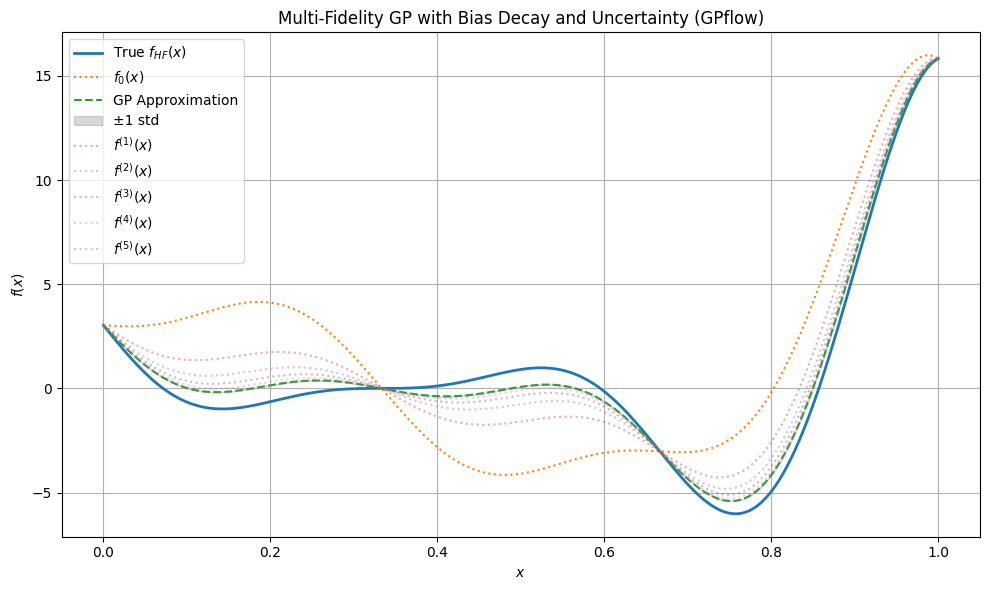

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import gpflow
import tensorflow as tf
from gpflow.models import GPR
from gpflow.kernels import SquaredExponential
from gpflow.mean_functions import Zero
from gpflow.optimizers import Scipy

# HF Forrester function
def f_HF(x):
    return ((6 * x - 2)**2) * np.sin(12 * x - 4)

# LF approximation
def f_k(x, k):
    return f_HF(x) + 5 * np.sin(3 * np.pi * x) / (k + 1)

# Telescoping term
def delta_k(x, k):
    return f_k(x, k) - f_k(x, k - 1) if k > 0 else f_k(x, 0)

# GP estimation with uncertainty propagation
def estimate_gpflow_with_uncertainty(x_grid, K_max=5, n_train=20):
    x_grid = x_grid.reshape(-1, 1)
    f0 = f_k(x_grid, 0).reshape(-1)
    f0_var = np.zeros_like(f0)

    delta_mu_list = []
    delta_var_list = []

    for k in range(1, K_max + 1):
        X_train = np.linspace(0, 1, n_train).reshape(-1, 1)
        Y_train = delta_k(X_train, k).reshape(-1, 1)

        kernel = SquaredExponential(lengthscales=0.2)
        kernel.variance.assign((1.0 / (k + 1))**2)  # bias decay

        model = GPR(data=(X_train, Y_train), kernel=kernel, mean_function=Zero())
        opt = Scipy()
        opt.minimize(model.training_loss, model.trainable_variables, options=dict(maxiter=100))

        mu, var = model.predict_f(x_grid)
        delta_mu_list.append(mu.numpy().reshape(-1))
        delta_var_list.append(var.numpy().reshape(-1))

    # Sum over deltas
    total_mean = f0 + np.sum(delta_mu_list, axis=0)
    total_std = np.sqrt(f0_var + np.sum(delta_var_list, axis=0))

    # Also return intermediate f^(k) for visualization
    f_k_series = [f0 + np.sum(delta_mu_list[:k], axis=0) for k in range(1, K_max + 1)]

    return total_mean, total_std, f_k_series

# === Run & Plot ===
x = np.linspace(0, 1, 200)
y_true = f_HF(x)
mean_pred, std_pred, f_k_list = estimate_gpflow_with_uncertainty(x, K_max=5)

plt.figure(figsize=(10, 6))
plt.plot(x, y_true, label="True $f_{HF}(x)$", linewidth=2)
plt.plot(x, f_k(x, 0), label="$f_0(x)$", linestyle=':')
plt.plot(x, mean_pred, label="GP Approximation", linestyle='--')

# Uncertainty band
plt.fill_between(x,
                 mean_pred - std_pred,
                 mean_pred + std_pred,
                 color='gray', alpha=0.3, label='±1 std')

# Optional: show convergence of f^(k)
for k, fk in enumerate(f_k_list):
    plt.plot(x, fk, linestyle=':', alpha=0.4, label=f"$f^{{({k+1})}}(x)$")

plt.xlabel("$x$")
plt.ylabel("$f(x)$")
plt.title("Multi-Fidelity GP with Bias Decay and Uncertainty (GPflow)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

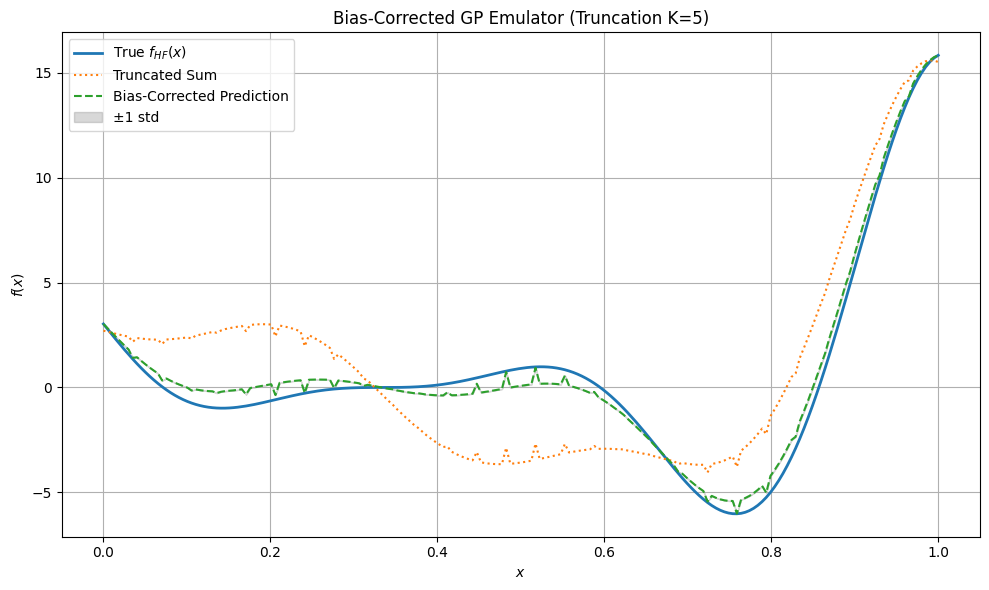

In [7]:
import numpy as np
import gpflow
from gpflow.kernels import SquaredExponential
from gpflow.mean_functions import Zero
from gpflow.models import GPR
from gpflow.optimizers import Scipy
import tensorflow as tf
import matplotlib.pyplot as plt

# ----------- 1. Define the Forrester function and LF hierarchy
def f_HF(x):
    return (6 * x - 2)**2 * np.sin(12 * x - 4)

def f_k(x, k):
    return f_HF(x) + 5 * np.sin(3 * np.pi * x) / (k + 1)

def delta_k(x, k):
    return f_k(x, k) - f_k(x, k - 1) if k > 0 else f_k(x, 0)

# ----------- 2. Generate training data for each delta_k
def generate_delta_data(K, num_points=30):
    X = np.linspace(0, 1, num_points).reshape(-1, 1)
    delta_data = []
    for k in range(1, K + 1):
        Y = delta_k(X, k)
        delta_data.append((X.copy(), Y.copy()))
    return delta_data, X

# ----------- 3. Fit GPs for each delta_k
def fit_delta_gps(delta_data):
    gp_models = []
    for X, Y in delta_data:
        kernel = SquaredExponential()
        model = GPR(data=(X, Y), kernel=kernel, mean_function=Zero())
        opt = Scipy()
        opt.minimize(model.training_loss, model.trainable_variables, options=dict(maxiter=100))
        gp_models.append(model)
    return gp_models

# ----------- 4. Fit bias GP based on HF - truncated sum
def fit_bias_gp(gp_models, X_train, K):
    y_true = f_HF(X_train)
    y_trunc = f_k(X_train, 0)
    for k in range(1, K + 1):
        y_trunc += gp_models[k - 1].predict_f(X_train)[0].numpy()
    residuals = y_true - y_trunc

    bias_gp = GPR(data=(X_train, residuals), kernel=SquaredExponential(), mean_function=Zero())
    opt = Scipy()
    opt.minimize(bias_gp.training_loss, bias_gp.trainable_variables, options=dict(maxiter=100))
    return bias_gp

# ----------- 5. Prediction function with bias correction
def predict_with_bias_correction(gp_models, bias_gp, X_query, K):
    f0 = f_k(X_query, 0)
    delta_sum = np.zeros_like(f0)
    for k in range(1, K + 1):
        mu, _ = gp_models[k - 1].predict_f(X_query)
        delta_sum += mu.numpy()
    f_trunc = f0 + delta_sum

    bias_mean, bias_var = bias_gp.predict_f(X_query)
    f_corrected = f_trunc + bias_mean.numpy()
    std = np.sqrt(bias_var.numpy())

    return f_corrected, std, f_trunc

# ----------- 6. Run everything
K = 5
delta_data, X_train = generate_delta_data(K)
gp_models = fit_delta_gps(delta_data)
bias_gp = fit_bias_gp(gp_models, X_train, K)

X_test = np.linspace(0, 1, 200).reshape(-1, 1)
f_corrected, f_std, f_trunc = predict_with_bias_correction(gp_models, bias_gp, X_test, K)
f_true = f_HF(X_test)

# ----------- 7. Plot result
plt.figure(figsize=(10,6))
plt.plot(X_test, f_true, label='True $f_{HF}(x)$', linewidth=2)
plt.plot(X_test, f_trunc, label='Truncated Sum', linestyle=':')
plt.plot(X_test, f_corrected, label='Bias-Corrected Prediction', linestyle='--')
plt.fill_between(X_test.flatten(),
                 (f_corrected - f_std).flatten(),
                 (f_corrected + f_std).flatten(),
                 color='gray', alpha=0.3, label='±1 std')
plt.legend()
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.title(f'Bias-Corrected GP Emulator (Truncation K={K})')
plt.grid(True)
plt.tight_layout()
plt.show()